# FFT Analysis — tremor_250
Power spectrum dos três eixos IMU (ch15=X, ch16=Y, ch17=Z).

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [28]:
def power_spectrum(sig, fs):
    s = sig - sig.mean()
    N = len(s)
    fft_vals = np.fft.rfft(s)
    freqs    = np.fft.rfftfreq(N, d=1.0/fs)
    power    = np.abs(fft_vals) ** 2
    return freqs, power

def load_imu(filepath):
    df = pd.read_csv(
        filepath, skiprows=5, header=None,
        names=['time_s','Thumb','Index','Middle','Ring','Pinky','ch15','ch16','ch17']
    )
    df = df[pd.to_numeric(df['time_s'], errors='coerce').notna()].reset_index(drop=True)
    df = df.astype(float)
    t  = df['time_s'].values
    fs = 1.0 / np.mean(np.diff(t))
    return df['ch15'].values, df['ch16'].values, df['ch17'].values, fs, t[-1]

def subtract_baseline(freqs_sig, power_sig, freqs_base, power_base):
    """Interpola baseline nos bins do sinal e subtrai (clip em 0 para evitar power negativo)."""
    base_interp = np.interp(freqs_sig, freqs_base, power_base)
    return np.maximum(power_sig - base_interp, 0)

def plot_axes(axs, axes_data, fs, dB=False):
    for ax, (freqs, power, label, color) in zip(axs, axes_data):
        y = 10 * np.log10(power + 1e-12) if dB else power
        ax.plot(freqs, y, color=color, linewidth=0.9, alpha=0.9)
        ax.set_ylabel('Power (dB)' if dB else 'Power (a.u.)', fontsize=10)
        ax.set_title(label, fontsize=11, fontweight='bold', color=color)
        ax.set_xlim(0, fs / 2)
        ax.grid(True, linestyle='--', alpha=0.4)
        if power.max() > 0:
            peaks, _ = find_peaks(power, height=power.max() * 0.05)
        else:
            peaks = np.array([], dtype=int)
        if len(peaks) == 0:
            peaks = np.argsort(power[1:])[::-1][:3] + 1
        top3 = sorted(peaks, key=lambda i: power[i], reverse=True)[:3]
        for pi in top3:
            yval = 10 * np.log10(power[pi] + 1e-12) if dB else power[pi]
            ynudge = yval - 1 if dB else yval * 0.98
            ax.annotate(
                f'{freqs[pi]:.1f} Hz',
                xy=(freqs[pi], yval),
                xytext=(freqs[pi] + 0.5, ynudge),
                fontsize=8, color='black',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
            )
    axs[-1].set_xlabel('Frequency (Hz)', fontsize=11)

# ─── Baseline (mão estável) ──────────────────────────────────────────────────
BASELINE = 'recordings/high_no_tremor_levelA_20260622_121901.csv'
bx, by, bz, fs_b, dur_b = load_imu(BASELINE)
fb_x, pb_x = power_spectrum(bx, fs_b)
fb_y, pb_y = power_spectrum(by, fs_b)
fb_z, pb_z = power_spectrum(bz, fs_b)
print(f'Baseline: {len(bx)} samples  |  Duração: {dur_b:.2f} s  |  fs ≈ {fs_b:.1f} Hz')

Baseline: 1204 samples  |  Duração: 20.02 s  |  fs ≈ 60.1 Hz


## Baseline — Power Spectrum (mão estável)

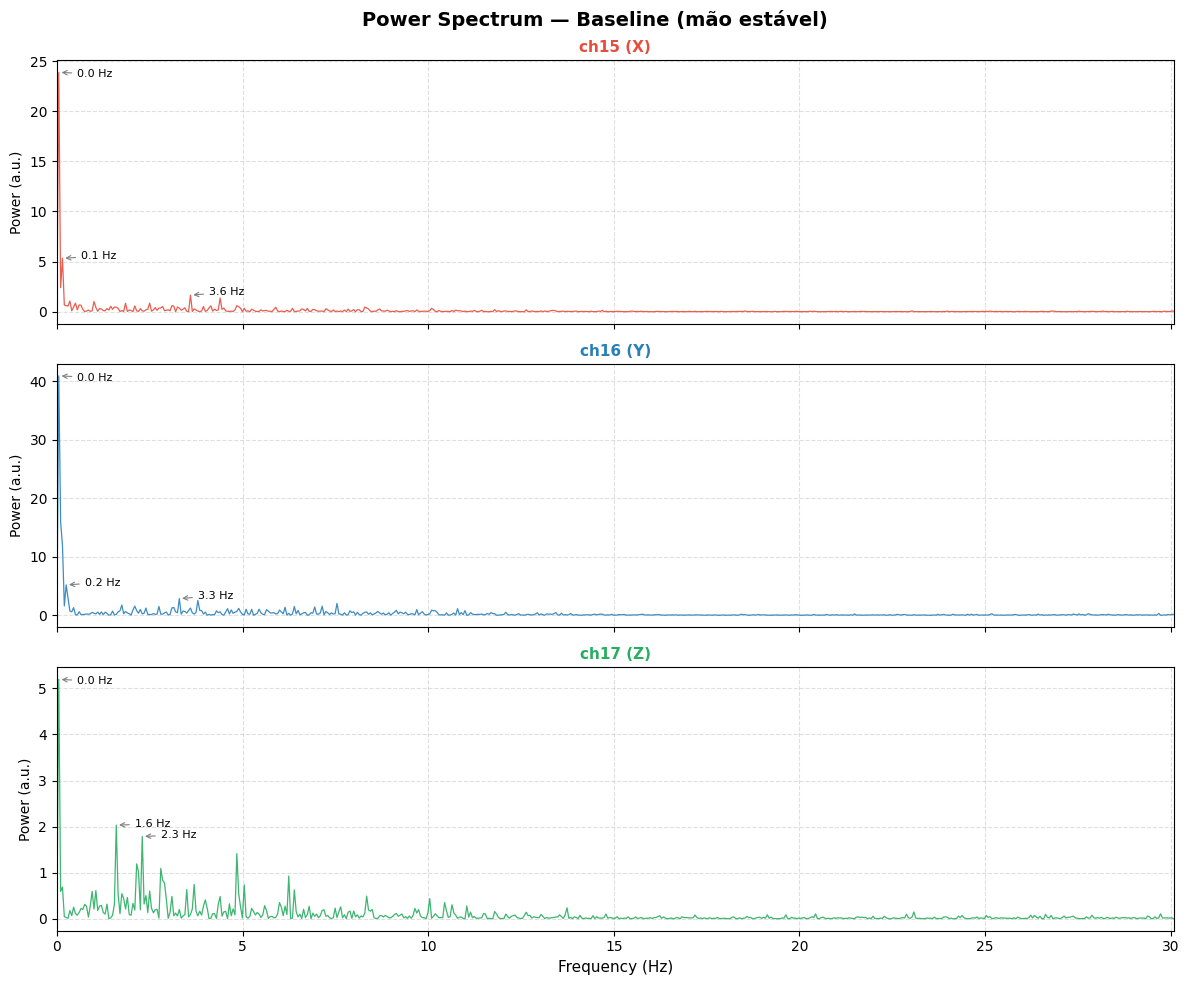

In [29]:
axes_baseline = [
    (fb_x, pb_x, 'ch15 (X)', '#e74c3c'),
    (fb_y, pb_y, 'ch16 (Y)', '#2980b9'),
    (fb_z, pb_z, 'ch17 (Z)', '#27ae60'),
]

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Power Spectrum — Baseline (mão estável)', fontsize=14, fontweight='bold')
plot_axes(axs, axes_baseline, fs_b, dB=False)
plt.tight_layout()
plt.savefig('baseline_power_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

## tremor_250 — Power Spectrum após subtração de baseline
Frequências da mão estável removidas; apenas picos do tremor permanecem.

tremor_250: 1204 samples  |  Duração: 20.00 s  |  fs ≈ 60.2 Hz


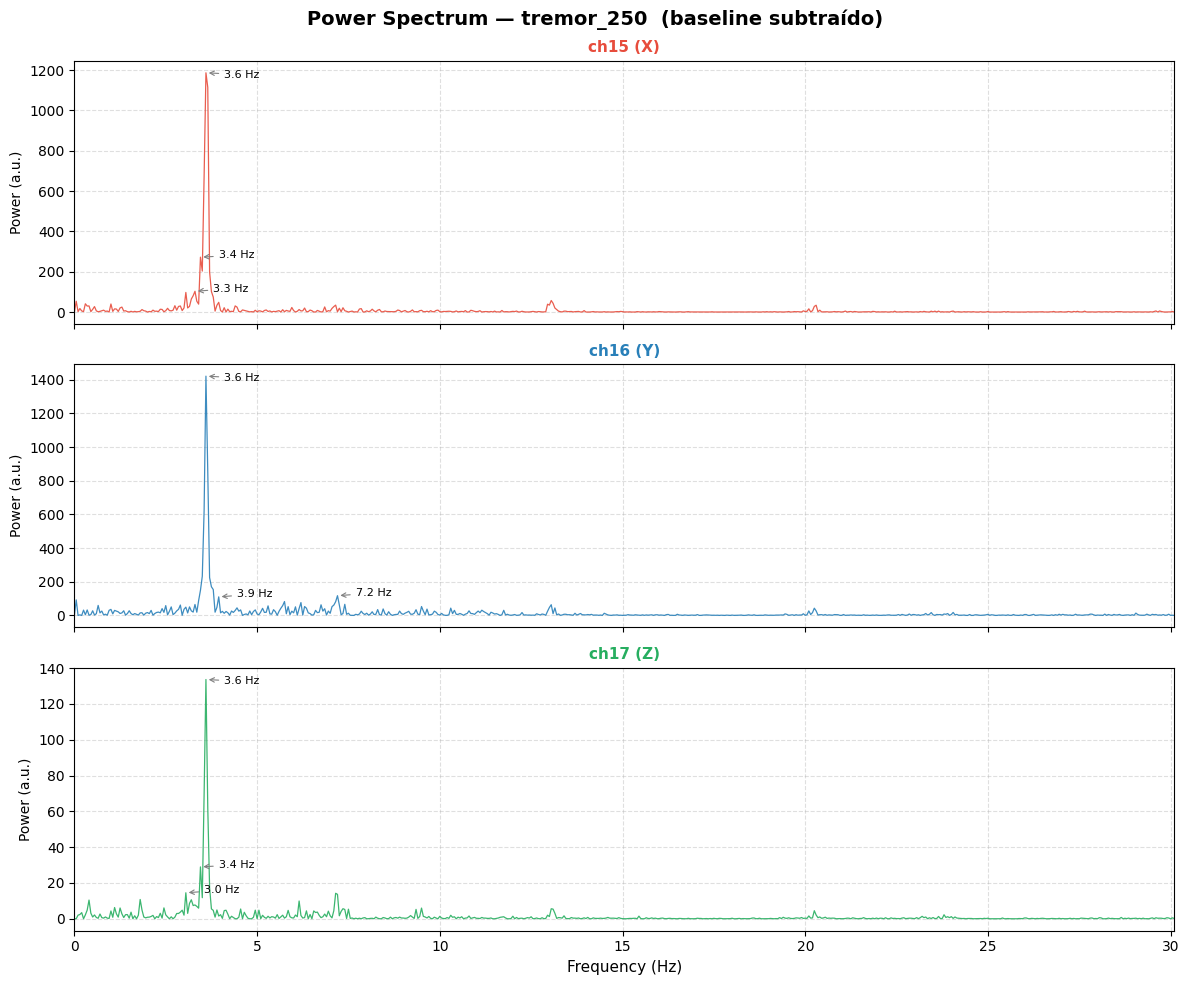

In [30]:
TREMOR250 = 'recordings/test8_tremor_250_levelA_20260619_122154.csv'
t250_x, t250_y, t250_z, fs_250, dur_250 = load_imu(TREMOR250)
print(f'tremor_250: {len(t250_x)} samples  |  Duração: {dur_250:.2f} s  |  fs ≈ {fs_250:.1f} Hz')

f250_x, p250_x = power_spectrum(t250_x, fs_250)
f250_y, p250_y = power_spectrum(t250_y, fs_250)
f250_z, p250_z = power_spectrum(t250_z, fs_250)

pd250_x = subtract_baseline(f250_x, p250_x, fb_x, pb_x)
pd250_y = subtract_baseline(f250_y, p250_y, fb_y, pb_y)
pd250_z = subtract_baseline(f250_z, p250_z, fb_z, pb_z)

axes_250 = [
    (f250_x, pd250_x, 'ch15 (X)', '#e74c3c'),
    (f250_y, pd250_y, 'ch16 (Y)', '#2980b9'),
    (f250_z, pd250_z, 'ch17 (Z)', '#27ae60'),
]

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Power Spectrum — tremor_250  (baseline subtraído)', fontsize=14, fontweight='bold')
plot_axes(axs, axes_250, fs_250, dB=False)
plt.tight_layout()
plt.savefig('tremor250_power_spectrum_baseline_sub.png', dpi=150, bbox_inches='tight')
plt.show()

### tremor_250 — Raw vs Baseline

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('tremor_250 — Raw vs Baseline', fontsize=14, fontweight='bold')

pairs_250 = [
    (fb_x, pb_x, f250_x, p250_x, 'ch15 (X)', '#e74c3c'),
    (fb_y, pb_y, f250_y, p250_y, 'ch16 (Y)', '#2980b9'),
    (fb_z, pb_z, f250_z, p250_z, 'ch17 (Z)', '#27ae60'),
]

for ax, (fb, pb, ft, pt, label, color) in zip(axs, pairs_250):
    ax.plot(fb, pb, color='#aaaaaa', linewidth=0.9, label='baseline')
    ax.plot(ft, pt, color=color,    linewidth=0.9, label='tremor_250 (raw)')
    ax.set_ylabel('Power (a.u.)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlim(0, fs_250 / 2)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8, loc='upper right')

axs[-1].set_xlabel('Frequency (Hz)', fontsize=11)
plt.tight_layout()
plt.savefig('tremor250_raw_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## tremor_500 — Power Spectrum após subtração de baseline
Frequências da mão estável removidas; apenas picos do tremor permanecem.

tremor_500: 1203 samples  |  Duração: 20.00 s  |  fs ≈ 60.1 Hz


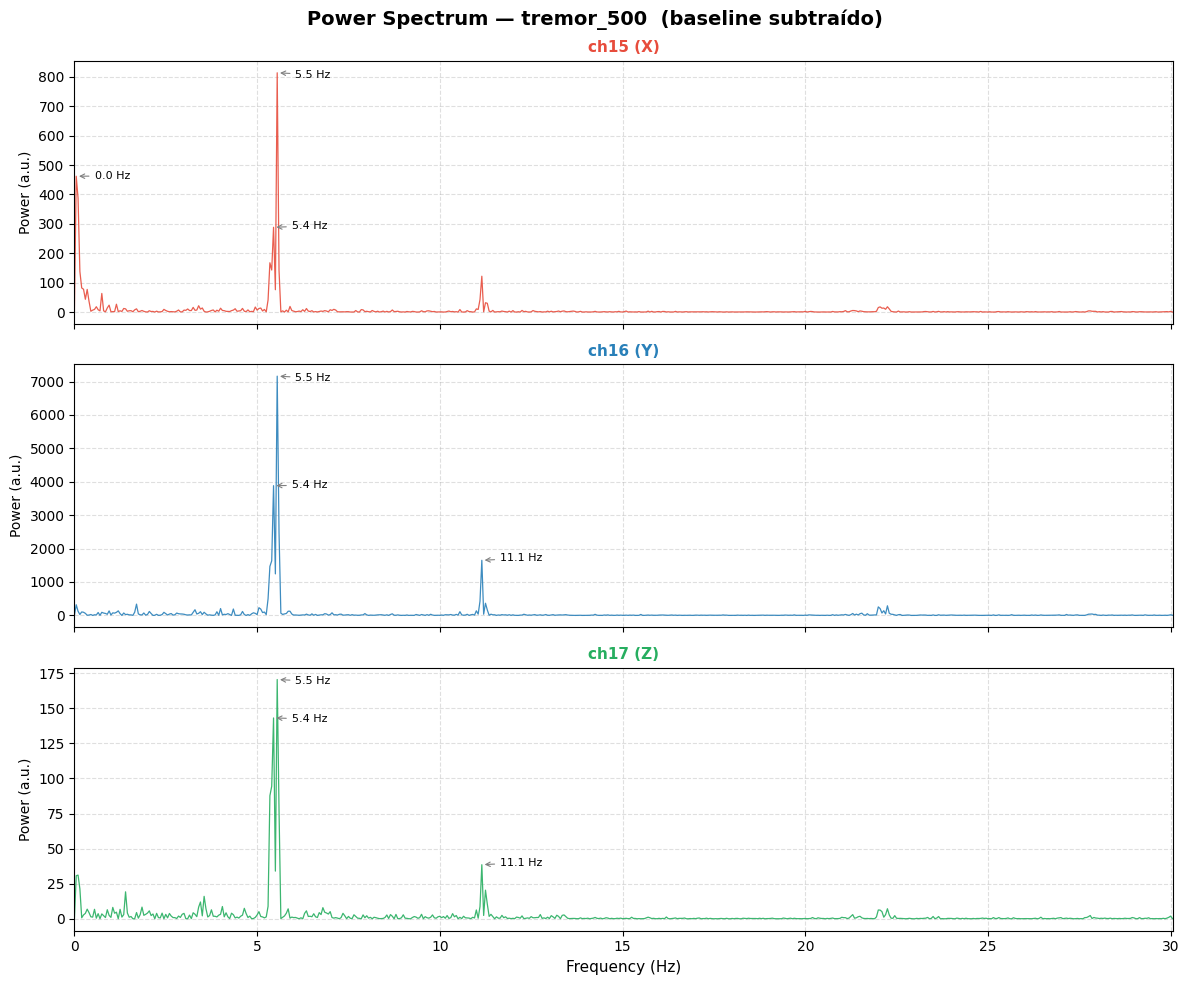

In [32]:
TREMOR500 = 'recordings/test8_500_levelA_20260619_122451.csv'
t500_x, t500_y, t500_z, fs_500, dur_500 = load_imu(TREMOR500)
print(f'tremor_500: {len(t500_x)} samples  |  Duração: {dur_500:.2f} s  |  fs ≈ {fs_500:.1f} Hz')

f500_x, p500_x = power_spectrum(t500_x, fs_500)
f500_y, p500_y = power_spectrum(t500_y, fs_500)
f500_z, p500_z = power_spectrum(t500_z, fs_500)

pd500_x = subtract_baseline(f500_x, p500_x, fb_x, pb_x)
pd500_y = subtract_baseline(f500_y, p500_y, fb_y, pb_y)
pd500_z = subtract_baseline(f500_z, p500_z, fb_z, pb_z)

axes_500 = [
    (f500_x, pd500_x, 'ch15 (X)', '#e74c3c'),
    (f500_y, pd500_y, 'ch16 (Y)', '#2980b9'),
    (f500_z, pd500_z, 'ch17 (Z)', '#27ae60'),
]

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Power Spectrum — tremor_500  (baseline subtraído)', fontsize=14, fontweight='bold')
plot_axes(axs, axes_500, fs_500, dB=False)
plt.tight_layout()
plt.savefig('tremor500_power_spectrum_baseline_sub.png', dpi=150, bbox_inches='tight')
plt.show()

### tremor_500 — Raw vs Baseline

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('tremor_500 — Raw vs Baseline', fontsize=14, fontweight='bold')

pairs_500 = [
    (fb_x, pb_x, f500_x, p500_x, 'ch15 (X)', '#e74c3c'),
    (fb_y, pb_y, f500_y, p500_y, 'ch16 (Y)', '#2980b9'),
    (fb_z, pb_z, f500_z, p500_z, 'ch17 (Z)', '#27ae60'),
]

for ax, (fb, pb, ft, pt, label, color) in zip(axs, pairs_500):
    ax.plot(fb, pb, color='#aaaaaa', linewidth=0.9, label='baseline')
    ax.plot(ft, pt, color=color,    linewidth=0.9, label='tremor_500 (raw)')
    ax.set_ylabel('Power (a.u.)', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlim(0, fs_500 / 2)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8, loc='upper right')

axs[-1].set_xlabel('Frequency (Hz)', fontsize=11)
plt.tight_layout()
plt.savefig('tremor500_raw_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## Picos dominantes por eixo (após subtração de baseline)

In [33]:
for title, axes_data in [('tremor_250', axes_250), ('tremor_500', axes_500)]:
    print(f'\n=== {title} ===')
    print(f"{'Eixo':<12} {'Freq (Hz)':>10} {'Power':>14}")
    print('-' * 40)
    for freqs, power, label, _ in axes_data:
        if power.max() > 0:
            peaks, _ = find_peaks(power, height=power.max() * 0.05)
        else:
            peaks = np.array([], dtype=int)
        if len(peaks) == 0:
            peaks = np.argsort(power[1:])[::-1][:3] + 1
        top = sorted(zip(power[peaks], freqs[peaks]), reverse=True)[:5]
        for pw, fr in top:
            print(f'{label:<12} {fr:>10.2f} {pw:>14.4e}')
        print()


=== tremor_250 ===
Eixo          Freq (Hz)          Power
----------------------------------------
ch15 (X)           3.60     1.1869e+03
ch15 (X)           3.45     2.7218e+02
ch15 (X)           3.30     1.0300e+02
ch15 (X)           3.05     9.7232e+01

ch16 (Y)           3.60     1.4209e+03
ch16 (Y)           7.20     1.1705e+02
ch16 (Y)           3.95     1.1012e+02
ch16 (Y)           0.05     9.2082e+01
ch16 (Y)           5.75     8.2324e+01

ch17 (Z)           3.60     1.3360e+02
ch17 (Z)           3.45     2.8958e+01
ch17 (Z)           3.05     1.4513e+01
ch17 (Z)           7.15     1.4228e+01
ch17 (Z)           1.80     1.0768e+01


=== tremor_500 ===
Eixo          Freq (Hz)          Power
----------------------------------------
ch15 (X)           5.55     8.1363e+02
ch15 (X)           0.05     4.6182e+02
ch15 (X)           5.45     2.8822e+02
ch15 (X)           5.35     1.6756e+02
ch15 (X)          11.15     1.2183e+02

ch16 (Y)           5.55     7.1614e+03
ch16 (Y)        